<a href="https://colab.research.google.com/github/19mddill/Machine_Learning_Projects/blob/main/decision_trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame = True)
X_iris = iris.data[["petal length (cm)","petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth = 2,random_state=42)
tree_clf.fit(X_iris,y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [2]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file = "iris_tree.dot",
    feature_names = iris.feature_names[2:],
    class_names = iris.target_names,
    rounded = True,
    filled = True
)

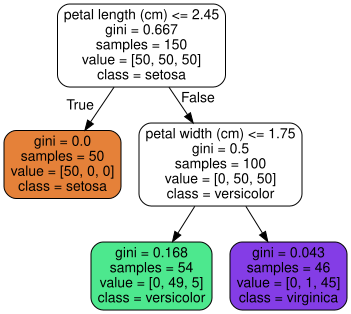

In [3]:
from graphviz import Source
Source.from_file("iris_tree.dot")

In [4]:
tree_clf.predict_proba([[6,1.5]]).round(3)

array([[0.   , 0.907, 0.093]])

In [5]:
tree_clf_ = DecisionTreeClassifier(max_depth = 3,random_state=42)
tree_clf_.fit(X_iris,y_iris)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [6]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf_,
    out_file = "iris_tree_.dot",
    feature_names = iris.feature_names[2:],
    class_names = iris.target_names,
    rounded = True,
    filled = True
)

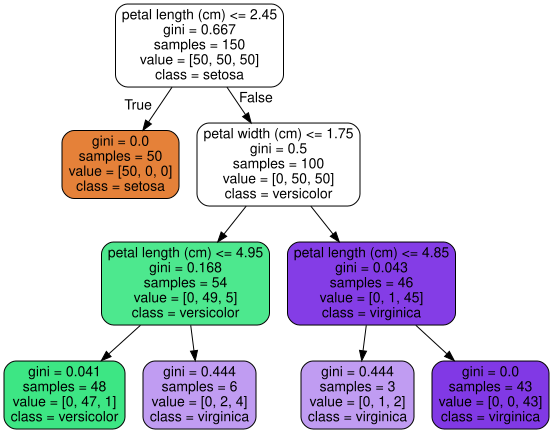

In [7]:
Source.from_file("iris_tree_.dot")

In [8]:
tree_clf_.predict_proba([[6,1.5]]).round(3)

array([[0.   , 0.333, 0.667]])

In [9]:
from sklearn.datasets import make_moons

X_moons,y_moons = make_moons(n_samples=150,noise=0.2,random_state=42)

tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5,random_state=42)
tree_clf1.fit(X_moons,y_moons)
tree_clf2.fit(X_moons,y_moons)

DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

In [10]:
X_moons_test,y_moons_test = make_moons(n_samples=1000,noise=0.2,random_state=42)

In [11]:
tree_clf1.score(X_moons_test,y_moons_test)

0.901

In [12]:
tree_clf2.score(X_moons_test,y_moons_test)

0.918

# Regression

In [13]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

In [14]:
np.random.seed(42)
X_quad = np.random.rand(200,1) - 0.5
y_quad = X_quad**2 + 0.025*np.random.randn(200,1)



In [15]:
tree_reg = DecisionTreeRegressor(max_depth=2,random_state=42)
tree_reg.fit(X_quad,y_quad)

DecisionTreeRegressor(max_depth=2, random_state=42)

# PCA


In [16]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pca_pipeline = make_pipeline(StandardScaler(),PCA())
X_iris_rotated = pca_pipeline.fit_transform(X_iris)
tree_clf_pca = DecisionTreeClassifier(max_depth = 2,random_state=42)
tree_clf_pca.fit(X_iris_rotated,y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)